In [1]:
!pip install textblob_fr     #for installation


In [2]:
import pandas as pd
from nltk.tokenize import sent_tokenize
from nltk.tokenize import word_tokenize
import re
import spacy
from spacy.lang.fr.stop_words import STOP_WORDS
import string
from textblob import Blobber
from textblob_fr import PatternTagger, PatternAnalyzer
tb = Blobber(pos_tagger=PatternTagger(), analyzer=PatternAnalyzer())
import plotly.graph_objects as go
import plotly.express as px


In [3]:
# Loading the Challenge dataset
challenge_dataset_path = ('/content/Challenge dataset.xlsx')
df_Volontaire = pd.read_excel(challenge_dataset_path, sheet_name= 'Volontaire')
df_2019 = pd.read_excel(challenge_dataset_path, sheet_name= '2019')

# Display the first few rows of each dataset
print("Volontaire Dataset:")
print(df_Volontaire.info())
print("\n2019 Dataset:")
print(df_2019.info())

Volontaire Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1846 entries, 0 to 1845
Data columns (total 40 columns):
 #   Column                                                                                     Non-Null Count  Dtype  
---  ------                                                                                     --------------  -----  
 0   ID                                                                                         1846 non-null   object 
 1   Age                                                                                        1846 non-null   int64  
 2   Horodateur                                                                                 1846 non-null   object 
 3   Niveau_d'etude                                                                             1846 non-null   object 
 4   Genre_                                                                                     1846 non-null   object 
 5   Taille_                     


 <font color='gris'> Check NAN values </font>

In [4]:
# Checking for missing values in both datasets
print("Missing values in Volontaire dataset:")
print(df_Volontaire.isnull().sum())

print("\nMissing values in 2019 dataset:")
print(df_2019.isnull().sum())

Missing values in Volontaire dataset:
ID                                                                                              0
Age                                                                                             0
Horodateur                                                                                      0
Niveau_d'etude                                                                                  0
Genre_                                                                                          0
Taille_                                                                                      1786
Poids                                                                                        1742
Situation_Matrimoniale_(SM)                                                                     0
Profession_                                                                                     0
Arrondissement_de_résidence_                                                    

 <font color='gris'> **Checking column names** </font>

In [5]:
# Displaying the columns in the Volontaires dataset
Volontaire_columns_list = list(df_Volontaire.columns)
print("Columns in volontaire dataset:")
print(Volontaire_columns_list)

# Displaying the columns in the 2019 dataset
data_2019_columns_list = list(df_2019.columns)
print("\nColumns in 2019 dataset:")
print(data_2019_columns_list)

Columns in volontaire dataset:
['ID', 'Age', 'Horodateur', "Niveau_d'etude", 'Genre_', 'Taille_', 'Poids', 'Situation_Matrimoniale_(SM)', 'Profession_', 'Arrondissement_de_résidence_', 'Quartier_de_Résidence_', 'Nationalité_', 'Religion_', 'A-t-il_(elle)_déjà_donné_le_sang_', 'Si_oui_preciser_la_date_du_dernier_don._', 'Taux_d’hémoglobine_', 'ÉLIGIBILITÉ_AU_DON.', 'Raison_indisponibilité__[Est_sous_anti-biothérapie__]', 'Raison_indisponibilité__[Taux_d’hémoglobine_bas_]', 'Raison_indisponibilité__[date_de_dernier_Don_<_3_mois_]', 'Raison_indisponibilité__[IST_récente_(Exclu_VIH,_Hbs,_Hcv)]', 'Date_de_dernières_règles_(DDR)__', 'Raison_de_l’indisponibilité_de_la_femme_[La_DDR_est_mauvais_si_<14_jour_avant_le_don]', 'Raison_de_l’indisponibilité_de_la_femme_[Allaitement_]', 'Raison_de_l’indisponibilité_de_la_femme_[A_accoucher_ces_6_derniers_mois__]', 'Raison_de_l’indisponibilité_de_la_femme_[Interruption_de_grossesse__ces_06_derniers_mois]', 'Raison_de_l’indisponibilité_de_la_femme_[est_

In [6]:
# Filling the missing values in the 'Si_autres_raison_préciser_' column with an empty string
df_Volontaire['Si_autres_raison_préciser_'] = df_Volontaire['Si_autres_raison_préciser_'].fillna('')
df_2019['Si autres raison préciser'] = df_2019['Si autres raison préciser'].fillna('')


 <font color='gris'> **Convert the data into lowercase**</font>

In [7]:
df_Volontaire["Si_autres_raison_préciser_"]= df_Volontaire["Si_autres_raison_préciser_"].str.lower()
df_2019["Si autres raison préciser"]= df_2019["Si autres raison préciser"].str.lower()


 <font color='gris'> **Word Tokenization and deleting punctuation** </font>

In [8]:
AComment=[]
for comment in df_Volontaire["Si_autres_raison_préciser_"].apply(str):
    Word_Tok = []
    for word in  re.sub("\W"," ",comment ).split():
        Word_Tok.append(word)
    AComment.append(Word_Tok)


In [9]:
AComment=[]
for comment in df_2019["Si autres raison préciser"].apply(str):
    Word_Tok = []
    for word in  re.sub("\W"," ",comment ).split():
        Word_Tok.append(word)
    AComment.append(Word_Tok)

 <font color='gris'> **Add New Column to our data** </font>

In [10]:
# Calculate the difference in lengths
diff = len(AComment) - len(df_Volontaire)

# Trim AComment to match the length of df_Volontaire
AComment = AComment[:len(df_Volontaire)]

# Now assign the trimmed list to the new column
df_Volontaire["Word_Tok"] = AComment
df_Volontaire.head()

,ID,Age,Horodateur,Niveau_d'etude,Genre_,Taille_,Poids,Situation_Matrimoniale_(SM),Profession_,Arrondissement_de_résidence_,...,Raison_de_non-eligibilité_totale__[Opéré],Raison_de_non-eligibilité_totale__[Drepanocytaire],Raison_de_non-eligibilité_totale__[Diabétique],Raison_de_non-eligibilité_totale__[Hypertendus],Raison_de_non-eligibilité_totale__[Asthmatiques],Raison_de_non-eligibilité_totale__[Cardiaque],Raison_de_non-eligibilité_totale__[Tatoué],Raison_de_non-eligibilité_totale__[Scarifié],Si_autres_raison_préciser_,Word_Tok
0,DONOR_1842,24,46:44.9,Universitaire,Homme,NaN,NaN,Célibataire,Etudiant (e),Douala 3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,[]
1,DONOR_1843,23,44:19.0,Universitaire,Homme,NaN,NaN,Célibataire,Sans Emplois,R A S,...,Oui,Non,Non,Non,Non,Non,Non,Non,,[]
2,DONOR_1844,41,46:54.3,Aucun,Homme,NaN,NaN,Marié (e),Tailleur,Douala 1,...,Non,Non,Non,Non,Non,Non,Non,Non,aucune information,[]
3,DONOR_1845,24,29:29.7,Universitaire,Homme,NaN,NaN,Célibataire,Etudiant,Douala 5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,[]
4,DONOR_1846,30,47:47.4,Secondaire,Homme,NaN,NaN,Célibataire,Militaire,Douala (Non précisé ),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,[]


<font color='gris'> **set of Spacy's default stop words and delete negation words** </font>

In [11]:
!python -m spacy download fr_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 74.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [12]:
import spacy
import re

# Load the French language model
nlp = spacy.load('fr_core_news_sm')

In [13]:
def clean_and_filter_text(text, additional_stop_words=None):
    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Zéèêëàâôùç\s]', '', text)

    # Process the text with spaCy
    doc = nlp(text)

    # Define the default stop words
    stop_words = set(nlp.Defaults.stop_words)

    # Add any additional stop words
    if additional_stop_words:
        stop_words.update(additional_stop_words)

    # Filter out stop words and return remaining words
    filtered_words = [token.text for token in doc if token.text.lower() not in stop_words and token.text.strip()]

    return filtered_words

<font color='gris'> **Add new Column: Comment after preprocessing** </font>

In [14]:
df_Volontaire["cleanedfeedback"] = df_Volontaire["Si_autres_raison_préciser_"].apply(clean_and_filter_text)
df_Volontaire.head()

,ID,Age,Horodateur,Niveau_d'etude,Genre_,Taille_,Poids,Situation_Matrimoniale_(SM),Profession_,Arrondissement_de_résidence_,...,Raison_de_non-eligibilité_totale__[Drepanocytaire],Raison_de_non-eligibilité_totale__[Diabétique],Raison_de_non-eligibilité_totale__[Hypertendus],Raison_de_non-eligibilité_totale__[Asthmatiques],Raison_de_non-eligibilité_totale__[Cardiaque],Raison_de_non-eligibilité_totale__[Tatoué],Raison_de_non-eligibilité_totale__[Scarifié],Si_autres_raison_préciser_,Word_Tok,cleanedfeedback
0,DONOR_1842,24,46:44.9,Universitaire,Homme,NaN,NaN,Célibataire,Etudiant (e),Douala 3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,[],[]
1,DONOR_1843,23,44:19.0,Universitaire,Homme,NaN,NaN,Célibataire,Sans Emplois,R A S,...,Non,Non,Non,Non,Non,Non,Non,,[],[]
2,DONOR_1844,41,46:54.3,Aucun,Homme,NaN,NaN,Marié (e),Tailleur,Douala 1,...,Non,Non,Non,Non,Non,Non,Non,aucune information,[],"[aucune, information]"
3,DONOR_1845,24,29:29.7,Universitaire,Homme,NaN,NaN,Célibataire,Etudiant,Douala 5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,[],[]
4,DONOR_1846,30,47:47.4,Secondaire,Homme,NaN,NaN,Célibataire,Militaire,Douala (Non précisé ),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,[],[]


<font color='gris'> **Sentiment Analysis with TextBlob** </font>

In [15]:
senti_list = []
for i in df_Volontaire["cleanedfeedback"]:
    # Join the list of words back into a single string
    text = " ".join(i)
    vs = tb(text).sentiment[0]
    if (vs > 0):
        senti_list.append('Positive')
    elif (vs < 0):
        senti_list.append('Negative')
    else:
        senti_list.append('Neutral')


<font color='gris'> **Add Column: Sentiment** </font>

In [16]:
df_Volontaire["sentiment"]=senti_list
df_Volontaire.head()

,ID,Age,Horodateur,Niveau_d'etude,Genre_,Taille_,Poids,Situation_Matrimoniale_(SM),Profession_,Arrondissement_de_résidence_,...,Raison_de_non-eligibilité_totale__[Diabétique],Raison_de_non-eligibilité_totale__[Hypertendus],Raison_de_non-eligibilité_totale__[Asthmatiques],Raison_de_non-eligibilité_totale__[Cardiaque],Raison_de_non-eligibilité_totale__[Tatoué],Raison_de_non-eligibilité_totale__[Scarifié],Si_autres_raison_préciser_,Word_Tok,cleanedfeedback,sentiment
0,DONOR_1842,24,46:44.9,Universitaire,Homme,NaN,NaN,Célibataire,Etudiant (e),Douala 3,...,NaN,NaN,NaN,NaN,NaN,NaN,,[],[],Neutral
1,DONOR_1843,23,44:19.0,Universitaire,Homme,NaN,NaN,Célibataire,Sans Emplois,R A S,...,Non,Non,Non,Non,Non,Non,,[],[],Neutral
2,DONOR_1844,41,46:54.3,Aucun,Homme,NaN,NaN,Marié (e),Tailleur,Douala 1,...,Non,Non,Non,Non,Non,Non,aucune information,[],"[aucune, information]",Neutral
3,DONOR_1845,24,29:29.7,Universitaire,Homme,NaN,NaN,Célibataire,Etudiant,Douala 5,...,NaN,NaN,NaN,NaN,NaN,NaN,,[],[],Neutral
4,DONOR_1846,30,47:47.4,Secondaire,Homme,NaN,NaN,Célibataire,Militaire,Douala (Non précisé ),...,NaN,NaN,NaN,NaN,NaN,NaN,,[],[],Neutral


**Data Visualization**

In [17]:
# Displaying the columns in the Volontaires dataset
Volontaire_columns_list = list(df_Volontaire.columns)
print("Columns in volontaire dataset:")
print(Volontaire_columns_list)

Columns in volontaire dataset:
['ID', 'Age', 'Horodateur', "Niveau_d'etude", 'Genre_', 'Taille_', 'Poids', 'Situation_Matrimoniale_(SM)', 'Profession_', 'Arrondissement_de_résidence_', 'Quartier_de_Résidence_', 'Nationalité_', 'Religion_', 'A-t-il_(elle)_déjà_donné_le_sang_', 'Si_oui_preciser_la_date_du_dernier_don._', 'Taux_d’hémoglobine_', 'ÉLIGIBILITÉ_AU_DON.', 'Raison_indisponibilité__[Est_sous_anti-biothérapie__]', 'Raison_indisponibilité__[Taux_d’hémoglobine_bas_]', 'Raison_indisponibilité__[date_de_dernier_Don_<_3_mois_]', 'Raison_indisponibilité__[IST_récente_(Exclu_VIH,_Hbs,_Hcv)]', 'Date_de_dernières_règles_(DDR)__', 'Raison_de_l’indisponibilité_de_la_femme_[La_DDR_est_mauvais_si_<14_jour_avant_le_don]', 'Raison_de_l’indisponibilité_de_la_femme_[Allaitement_]', 'Raison_de_l’indisponibilité_de_la_femme_[A_accoucher_ces_6_derniers_mois__]', 'Raison_de_l’indisponibilité_de_la_femme_[Interruption_de_grossesse__ces_06_derniers_mois]', 'Raison_de_l’indisponibilité_de_la_femme_[est_

In [18]:
Number_sentiment = df_Volontaire.groupby(["sentiment"])["Si_autres_raison_préciser_"].count().reset_index().reset_index(drop=True)

In [20]:
fig = px.histogram(df_Volontaire, x="sentiment",color="sentiment")
fig.update_layout(
    title_text='Sentiment of reviews', # title of plot
    xaxis_title_text='Sentiment', # xaxis label
    yaxis_title_text='Count', # yaxis label
    bargap=0.2,
    bargroupgap=0.1
)
fig.show()

In [21]:
fig = px.pie(Number_sentiment, values=Number_sentiment['Si_autres_raison_préciser_'], names=Number_sentiment['sentiment'], color_discrete_sequence=px.colors.sequential.Emrld
)
fig.show()

In [23]:
pip install wordcloud matplotlib

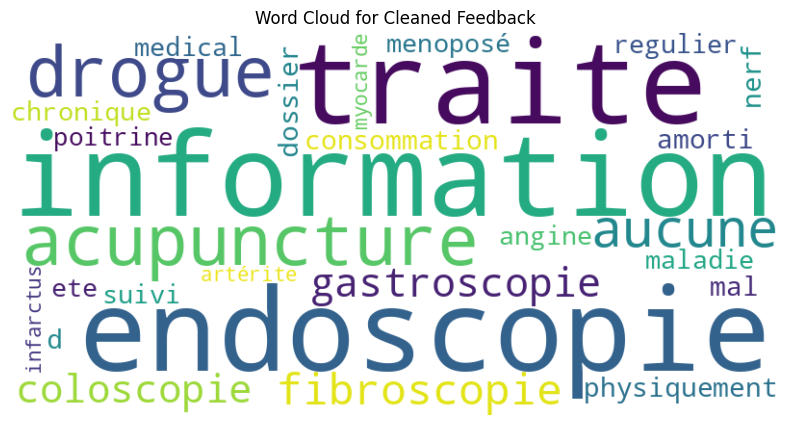

In [26]:
import pandas as pd
import spacy
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Load the French language model
nlp = spacy.load('fr_core_news_sm')

# Function to clean and filter text
def clean_and_filter_text(text):
    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Zéèêëàâôùç\s]', '', text)

    # Process the text with spaCy
    doc = nlp(text)

    # Filter out stop words and return remaining words
    filtered_words = [token.text for token in doc if not token.is_stop and token.text.strip()]

    return ' '.join(filtered_words)  # Return as a single string

# Clean and filter the feedback text
df_Volontaire['cleaned_feedback'] = df_Volontaire['Si_autres_raison_préciser_'].apply(clean_and_filter_text)

# Combine all cleaned feedback into a single string
combined_feedback = ' '.join(df_Volontaire['cleaned_feedback'])

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(combined_feedback)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Hide axes
plt.title('Word Cloud for Cleaned Feedback')
plt.show()

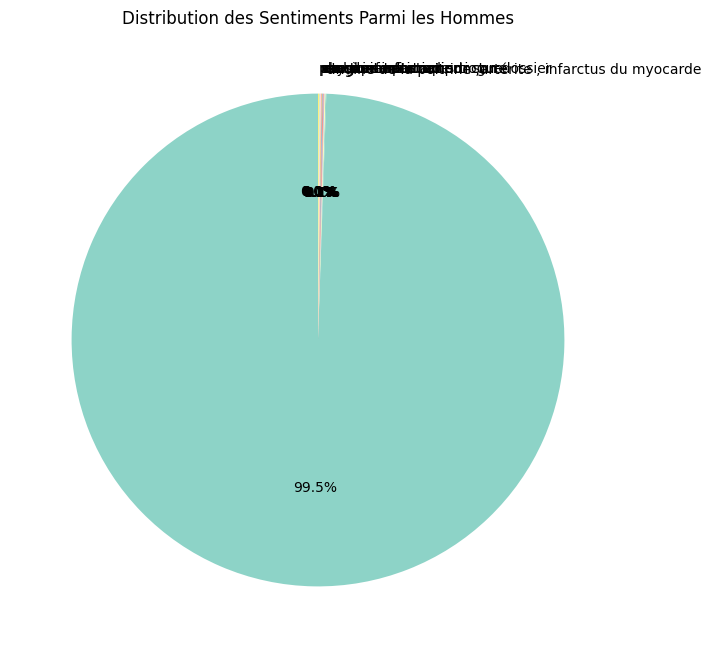

In [28]:
# Count sentiments by demographic group (e.g., Genre_)
sentiment_by_gender = df_Volontaire.groupby('Genre_')['Si_autres_raison_préciser_'].value_counts().unstack(fill_value=0)

# Create a pie chart for one gender category (e.g., Male)
if 'Homme' in sentiment_by_gender.index:
    male_sentiment_distribution = sentiment_by_gender.loc['Homme']
else:
    print("No data for 'Homme' in the dataset.")

# Plotting the pie chart
plt.figure(figsize=(8, 8))
male_sentiment_distribution.plot(kind='pie', autopct='%1.1f%%', startangle=90, cmap='Set3')
plt.title('Distribution des Sentiments Parmi les Hommes')
plt.ylabel('')  # Hide the y label
plt.show()